In [298]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

from y0.graph import NxMixedGraph
from y0.algorithm.ioscm.utils import get_apt_order, get_strongly_connected_components

In [299]:
graphml_path = "../ecoli_full_network_no_small_rna.graphml"

In [300]:
g = nx.read_graphml(graphml_path)

In [301]:
print(len(g.edges))
print(len(g.nodes))

9211
2976


In [302]:
out_degree = dict(g.out_degree)
out_degree_list = sorted(list(out_degree.items()), key=lambda x: x[1], reverse=True)
in_degree = dict(g.in_degree)
in_degree_list = sorted(list(in_degree.items()), key=lambda x: x[1], reverse=True)
degree = dict(g.degree)
degree_list = sorted(list(degree.items()), key=lambda x: x[1], reverse=True)

In [303]:
out_degree_list[:20]

[('rpoD', 1662),
 ('crp', 559),
 ('nac', 529),
 ('lrp', 361),
 ('rpoS', 328),
 ('fnr', 320),
 ('fis', 245),
 ('arcA', 231),
 ('ihfA', 227),
 ('ihfB', 227),
 ('hns', 224),
 ('fur', 207),
 ('rpoH', 172),
 ('dksA', 156),
 ('rpoN', 142),
 ('rpoE', 126),
 ('narL', 124),
 ('cpxR', 122),
 ('glaR', 120),
 ('flhC', 92)]

In [304]:
np.unique_counts(list(out_degree.values()))

UniqueCountsResult(values=array([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
         11,   12,   13,   14,   15,   16,   17,   18,   21,   22,   23,
         24,   26,   27,   28,   30,   32,   33,   37,   38,   42,   43,
         44,   46,   48,   49,   50,   51,   53,   56,   57,   61,   62,
         63,   72,   78,   85,   92,  120,  122,  124,  126,  142,  156,
        172,  207,  224,  227,  231,  245,  320,  328,  361,  529,  559,
       1662]), counts=array([2691,   23,   36,   30,   24,   16,   15,   12,   12,    9,   13,
          6,    7,    5,    6,    6,    1,    4,    2,    3,    1,    2,
          1,    1,    1,    1,    1,    2,    2,    1,    1,    1,    1,
          1,    1,    2,    1,    1,    1,    2,    1,    1,    1,    2,
          1,    1,    1,    1,    2,    1,    1,    1,    1,    1,    1,
          1,    1,    1,    2,    1,    1,    1,    1,    1,    1,    1,
          1]))

In [305]:
min(out_degree.values()), np.mean(list(out_degree.values())), np.median(list(out_degree.values())), max(out_degree.values())

(0, np.float64(3.0950940860215055), np.float64(0.0), 1662)

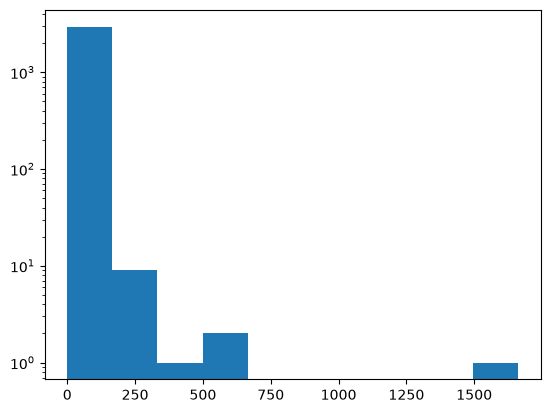

In [306]:
plt.hist(list(out_degree.values()))
plt.yscale("log")

In [307]:
in_degree_list[:20]

[('csgD', 20),
 ('csgE', 20),
 ('csgF', 20),
 ('csgG', 20),
 ('flhC', 17),
 ('flhD', 17),
 ('gadX', 17),
 ('gltF', 16),
 ('rsd', 15),
 ('gadW', 15),
 ('gadA', 14),
 ('gadB', 14),
 ('gltD', 14),
 ('gadE', 14),
 ('gltB', 13),
 ('rmf', 13),
 ('rpoE', 13),
 ('rseA', 13),
 ('fliA', 13),
 ('gadC', 12)]

In [308]:
np.unique_counts(list(in_degree.values()))

UniqueCountsResult(values=array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 20]), counts=array([ 54, 821, 671, 470, 315, 231, 143, 114,  54,  37,  23,  14,  10,
         5,   4,   2,   1,   3,   4]))

In [309]:
min(in_degree.values()), np.mean(list(in_degree.values())), np.median(list(in_degree.values())), max(in_degree.values())

(0, np.float64(3.0950940860215055), np.float64(2.0), 20)

(array([ 875., 1141.,  546.,  257.,   91.,   37.,   15.,    6.,    4.,
           4.]),
 array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14., 16., 18., 20.]),
 <BarContainer object of 10 artists>)

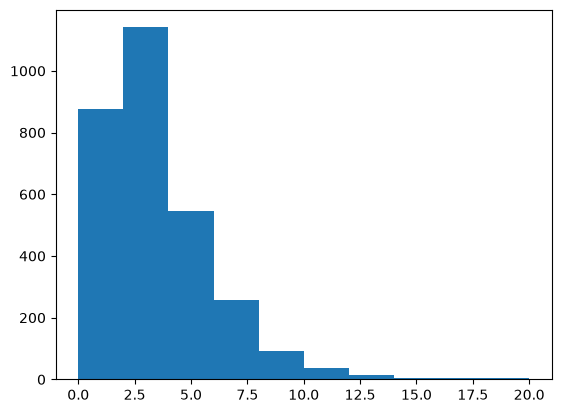

In [310]:
plt.hist(list(in_degree.values()))

In [311]:
degree_list[:20]

[('rpoD', 1667),
 ('crp', 563),
 ('nac', 535),
 ('lrp', 368),
 ('rpoS', 336),
 ('fnr', 326),
 ('fis', 252),
 ('arcA', 234),
 ('ihfA', 232),
 ('ihfB', 232),
 ('hns', 229),
 ('fur', 212),
 ('rpoH', 183),
 ('dksA', 159),
 ('rpoN', 145),
 ('rpoE', 139),
 ('narL', 127),
 ('cpxR', 125),
 ('glaR', 120),
 ('flhC', 109)]

In [312]:
np.unique_counts(list(degree.values()))

UniqueCountsResult(values=array([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
         11,   12,   13,   14,   15,   16,   17,   18,   19,   20,   22,
         23,   24,   26,   28,   29,   30,   32,   33,   35,   36,   37,
         38,   46,   48,   49,   50,   52,   55,   57,   58,   59,   62,
         64,   65,   66,   67,   80,   85,  109,  120,  125,  127,  139,
        145,  159,  183,  212,  229,  232,  234,  252,  326,  336,  368,
        535,  563, 1667]), counts=array([ 14, 790, 638, 431, 291, 227, 147, 129,  69,  44,  32,  21,  20,
        14,  13,   8,   7,   7,   4,   1,   5,   4,   1,   1,   3,   2,
         1,   1,   1,   1,   2,   1,   1,   1,   2,   3,   1,   1,   3,
         1,   1,   1,   1,   1,   2,   1,   1,   1,   1,   2,   2,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   2,   1,   1,   1,   1,
         1,   1,   1,   1]))

In [313]:
min(degree.values()), np.mean(list(degree.values())), np.median(list(degree.values())), max(degree.values())

(0, np.float64(6.190188172043011), np.float64(3.0), 1667)

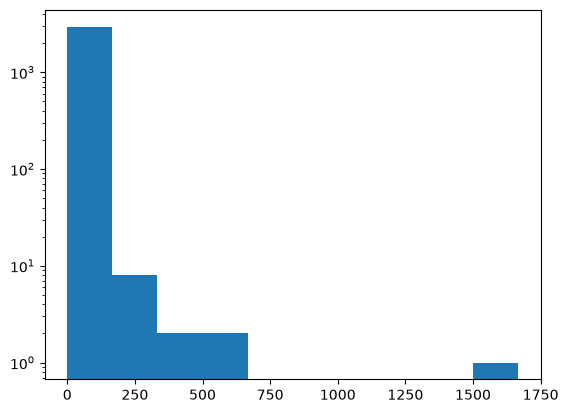

In [314]:
plt.hist(list(degree.values()))
plt.yscale('log')

In [315]:
sccs = sorted(list(nx.strongly_connected_components(g)), key=lambda x: len(x), reverse=True)
sccs[:5]

[{'acrR',
  'adiY',
  'arcA',
  'argP',
  'argR',
  'bglJ',
  'bolA',
  'cpxR',
  'cra',
  'crp',
  'csgD',
  'cspA',
  'csrA',
  'cytR',
  'deaD',
  'dksA',
  'dnaA',
  'evgA',
  'fis',
  'flhC',
  'flhD',
  'fliA',
  'fliZ',
  'fnr',
  'fur',
  'gadE',
  'gadW',
  'gadX',
  'glnG',
  'hdfR',
  'hns',
  'ihfA',
  'ihfB',
  'leuO',
  'lexA',
  'lldR',
  'lrhA',
  'lrp',
  'matA',
  'mlrA',
  'mqsA',
  'nac',
  'ompR',
  'oxyR',
  'phoB',
  'phoP',
  'qseB',
  'rcsA',
  'rcsB',
  'rpoD',
  'rpoE',
  'rpoH',
  'rpoN',
  'rpoS',
  'rpsA',
  'rstA',
  'rutR',
  'sdiA',
  'slyA',
  'soxR',
  'soxS',
  'stpA',
  'sutR',
  'torR',
  'ydeO',
  'ydiP',
  'yjjQ',
  'zraR'},
 {'marA', 'marR', 'rob'},
 {'accA', 'accD'},
 {'gutM', 'srlR'},
 {'dinJ', 'yafQ'}]

In [316]:
len(sccs[0]), len(sccs[1])

(68, 3)

In [317]:
directed_edges = list(g.edges())
g_mixed = NxMixedGraph.from_edges(directed=directed_edges)

# precompute apt-order once for the full graph
apt_order = [node.name for node in get_apt_order(g_mixed)]
apt_order

['nanR',
 'ycjW',
 'ygbI',
 'glaR',
 'modE',
 'nsrR',
 'kdpE',
 'rcdA',
 'ptrR',
 'deoR',
 'yidZ',
 'ulaR',
 'hypT',
 'selB',
 'atoC',
 'frmR',
 'zur',
 'basR',
 'dicF',
 'yiaU',
 'pgrR',
 'nimR',
 'yhaJ',
 'glrR',
 'cueR',
 'gatR',
 'citR',
 'birA',
 'btsR',
 'c0293',
 'rclR',
 'yfeC',
 'racR',
 'alpA',
 'fimZ',
 'dicD',
 'srmB',
 'pyrR',
 'envY',
 'nadR',
 'fabR',
 'ralA',
 'yrdG',
 'envR',
 'ebgR',
 'ameF',
 'punR',
 'ycjN',
 'ycjO',
 'ycjV',
 'ycjM',
 'ompG',
 'ycjS',
 'ycjQ',
 'ycjR',
 'ycjU',
 'ycjT',
 'ygbJ',
 'ycgY',
 'ycbU',
 'yigG',
 'yfdC',
 'yjdP',
 'ypdC',
 'yehD',
 'priC',
 'yihM',
 'yciU',
 'rsgA',
 'ypjA',
 'yfbO',
 'yjfY',
 'ydhS',
 'orn',
 'ycjP',
 'yfbU',
 'kdgT',
 'yehS',
 'ycbV',
 'ydfI',
 'yidB',
 'ynaE',
 'smg',
 'hinT',
 'yqhC',
 'elfC',
 'rhsD',
 'yfbN',
 'bdcR',
 'yodB',
 'yfjD',
 'yccU',
 'hxpA',
 'mrdA',
 'yadN',
 'yfcV',
 'norR',
 'tehA',
 'tehB',
 'ybjJ',
 'ybjI',
 'glsB',
 'yneG',
 'ppiC',
 'selA',
 'frmA',
 'pliG',
 'dgkA',
 'arnT',
 'arnD',
 'arnA',
 'a

In [318]:
dec_from_scc = []
for node in list(sccs[0]):
    dec_from_scc.extend(nx.descendants(g, node))

dec_from_scc_set = set(dec_from_scc)

In [319]:
candidate_nodes_in_apt_order = list(set(apt_order) - dec_from_scc_set)  # Ignore largest SCCs for apt-ordering

In [320]:
candidate_nodes_in_apt_order

['yjfY',
 'punC',
 'ygiD',
 'elfC',
 'arnB',
 'ypdC',
 'yfdC',
 'dgkA',
 'envR',
 'cueO',
 'yodB',
 'yneG',
 'srmB',
 'ycjR',
 'ydaS',
 'ypjA',
 'yhaL',
 'bdcR',
 'kdgT',
 'yfbU',
 'fimZ',
 'yfeC',
 'alpA',
 'ydfI',
 'ycjM',
 'racR',
 'rclR',
 'frmR',
 'ralR',
 'ebgR',
 'arnF',
 'envY',
 'citR',
 'ycjG',
 'ygbI',
 'yhaJ',
 'hxpA',
 'intA',
 'yqhC',
 'norR',
 'modE',
 'birA',
 'atoC',
 'sfmC',
 'kdpE',
 'yiaT',
 'yehS',
 'nimR',
 'yfcV',
 'ompG',
 'ydaW',
 'ycjP',
 'ycjU',
 'yidZ',
 'ydhS',
 'tehB',
 'ydaV',
 'tehA',
 'adeP',
 'nimT',
 'rhsD',
 'zur',
 'arnT',
 'ralA',
 'orn',
 'pliG',
 'ycjO',
 'ycjQ',
 'dicD',
 'rcdA',
 'punR',
 'arnA',
 'ycgY',
 'nadA',
 'gatR',
 'mrdA',
 'yiaU',
 'pyrR',
 'mppA',
 'glsB',
 'nanR',
 'nadR',
 'ycjN',
 'arnC',
 'btsR',
 'yhaK',
 'ptrR',
 'yadN',
 'rsgA',
 'ynaE',
 'ycjW',
 'glaR',
 'yihM',
 'basR',
 'glrR',
 'selB',
 'ameF',
 'dicF',
 'ybjI',
 'yjdP',
 'dicA',
 'smg',
 'yfjD',
 'ppiC',
 'yciU',
 'yigG',
 'ycjT',
 'ycjS',
 'priC',
 'ycjV',
 'yidB',
 'de

In [321]:
len(candidate_nodes_in_apt_order)

139

In [347]:
N = 500

In [348]:
subgraph_nodes = set()

In [352]:
i = 0
while(len(subgraph_nodes) < N and i < len(candidate_nodes_in_apt_order)):
    node = candidate_nodes_in_apt_order[i]
    subgraph_nodes.add(node)
    ancestors = nx.ancestors(g, node)
    print(f"{len(ancestors)} ancestors for node {node}")
    for anc in nx.ancestors(g, node):
        subgraph_nodes.add(anc)
    i += 1

1 ancestors for node yjfY
1 ancestors for node punC
1 ancestors for node ygiD
1 ancestors for node elfC
1 ancestors for node arnB
1 ancestors for node ypdC
1 ancestors for node yfdC
1 ancestors for node dgkA
0 ancestors for node envR
1 ancestors for node cueO
1 ancestors for node yodB
1 ancestors for node yneG
0 ancestors for node srmB
1 ancestors for node ycjR
1 ancestors for node ydaS
1 ancestors for node ypjA
1 ancestors for node yhaL
1 ancestors for node bdcR
1 ancestors for node kdgT
1 ancestors for node yfbU
0 ancestors for node fimZ
0 ancestors for node yfeC
0 ancestors for node alpA
1 ancestors for node ydfI
1 ancestors for node ycjM
0 ancestors for node racR
0 ancestors for node rclR
0 ancestors for node frmR
1 ancestors for node ralR
0 ancestors for node ebgR
1 ancestors for node arnF
0 ancestors for node envY
0 ancestors for node citR
1 ancestors for node ycjG
0 ancestors for node ygbI
0 ancestors for node yhaJ
1 ancestors for node hxpA
1 ancestors for node intA
1 ancestors 

In [353]:
i

139

In [354]:
subgraph = g.subgraph(subgraph_nodes)

In [355]:
subgraph = g.subgraph(
    [node for node in subgraph_nodes if g.subgraph(subgraph_nodes).degree(node) > 0]
).copy()

In [356]:
print(len(subgraph.edges))
print(len(subgraph.nodes))

104
117


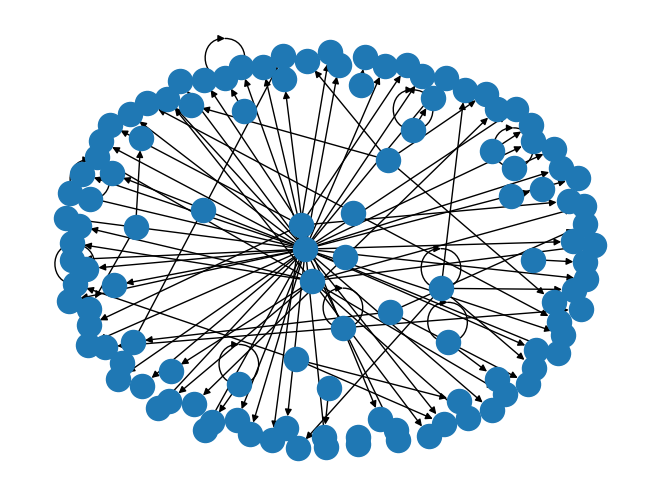

In [357]:
nx.draw(subgraph)

In [370]:
out_degree = dict(subgraph.out_degree)
out_degree_list = sorted(list(out_degree.items()), key=lambda x: x[1], reverse=True)
in_degree = dict(subgraph.in_degree)
in_degree_list = sorted(list(in_degree.items()), key=lambda x: x[1], reverse=True)
degree = dict(subgraph.degree)
degree_list = sorted(list(degree.items()), key=lambda x: x[1], reverse=True)

In [359]:
out_degree_list[:20]

[('glaR', 40),
 ('ycjW', 11),
 ('basR', 8),
 ('yhaJ', 5),
 ('yiaU', 4),
 ('racR', 3),
 ('rcdA', 3),
 ('nsrR', 3),
 ('fimZ', 2),
 ('frmR', 2),
 ('citR', 2),
 ('nimR', 2),
 ('nadR', 2),
 ('ptrR', 2),
 ('selB', 2),
 ('pgrR', 2),
 ('yfeC', 1),
 ('alpA', 1),
 ('ygbI', 1),
 ('norR', 1)]

In [360]:
in_degree_list[:20]

[('norR', 2),
 ('ycjP', 2),
 ('tehA', 2),
 ('pliG', 2),
 ('dicA', 2),
 ('yjfY', 1),
 ('punC', 1),
 ('ygiD', 1),
 ('elfC', 1),
 ('arnB', 1),
 ('ypdC', 1),
 ('yfdC', 1),
 ('dgkA', 1),
 ('cueO', 1),
 ('yodB', 1),
 ('yneG', 1),
 ('ycjR', 1),
 ('ydaS', 1),
 ('ypjA', 1),
 ('yhaL', 1)]

In [371]:
subgraph_sccs = sorted(list(nx.strongly_connected_components(subgraph)), key=lambda x: len(x), reverse=True)
subgraph_sccs

[{'yjfY'},
 {'punC'},
 {'ygiD'},
 {'elfC'},
 {'arnB'},
 {'ypdC'},
 {'yfdC'},
 {'dgkA'},
 {'cueO'},
 {'yodB'},
 {'yneG'},
 {'ycjR'},
 {'ydaS'},
 {'ypjA'},
 {'yhaL'},
 {'bdcR'},
 {'kdgT'},
 {'yfbU'},
 {'sfmA'},
 {'sfmC'},
 {'fimZ'},
 {'yfeC'},
 {'intA'},
 {'alpA'},
 {'ydfI'},
 {'ycjM'},
 {'ydaV'},
 {'ydaW'},
 {'racR'},
 {'frmA'},
 {'frmR'},
 {'ralR'},
 {'arnF'},
 {'ybdM'},
 {'citR'},
 {'ycjG'},
 {'ygbJ'},
 {'ygbI'},
 {'yhaK'},
 {'yqjF'},
 {'yhaJ'},
 {'hxpA'},
 {'yqhC'},
 {'norR'},
 {'yiaT'},
 {'yehS'},
 {'nimT'},
 {'nimR'},
 {'yfcV'},
 {'ompG'},
 {'ycjP'},
 {'ycjU'},
 {'ppiC'},
 {'yidZ'},
 {'ydhS'},
 {'tehB'},
 {'tehA'},
 {'adeP'},
 {'rhsD'},
 {'pliG'},
 {'zur'},
 {'arnT'},
 {'ralA'},
 {'orn'},
 {'ycjO'},
 {'ycjQ'},
 {'dicA'},
 {'dicD'},
 {'ybjI'},
 {'ybjJ'},
 {'rcdA'},
 {'punR'},
 {'arnA'},
 {'ycgY'},
 {'nadA'},
 {'mrdA'},
 {'yiaV'},
 {'yiaW'},
 {'yiaU'},
 {'mppA'},
 {'glsB'},
 {'pnuC'},
 {'nadR'},
 {'ycjN'},
 {'arnC'},
 {'ptrR'},
 {'yadN'},
 {'rsgA'},
 {'ynaE'},
 {'ycjS'},
 {'ycjT'},
 

In [372]:
degree_list[:20]

[('glaR', 40),
 ('ycjW', 11),
 ('basR', 8),
 ('yhaJ', 6),
 ('rcdA', 4),
 ('yiaU', 4),
 ('racR', 3),
 ('frmR', 3),
 ('citR', 3),
 ('norR', 3),
 ('nimR', 3),
 ('selB', 3),
 ('dicA', 3),
 ('nsrR', 3),
 ('fimZ', 2),
 ('yfeC', 2),
 ('ycjP', 2),
 ('tehA', 2),
 ('pliG', 2),
 ('nadR', 2)]

(array([113.,   2.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([ 1. ,  4.9,  8.8, 12.7, 16.6, 20.5, 24.4, 28.3, 32.2, 36.1, 40. ]),
 <BarContainer object of 10 artists>)

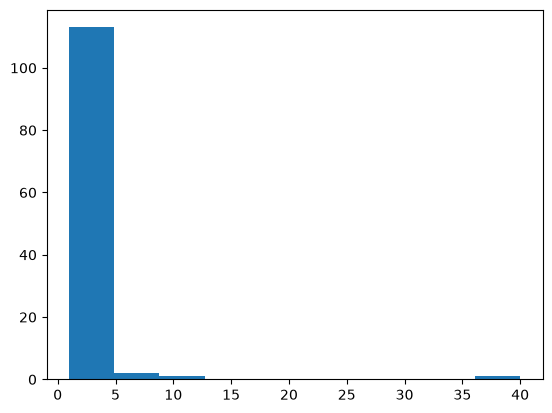

In [373]:
plt.hist(degree.values())

In [362]:
from nocap.cyclic_single_door import classify_edge, nx_digraph_to_y0
from y0.algorithm.separation.sigma_extension import sigma_extension


precomputed_y0 = nx_digraph_to_y0(subgraph)
precomputed_extension = sigma_extension(precomputed_y0)

res = []

self_loop = 0

for (cause, effect) in subgraph.edges:
    if cause == effect:
        self_loop += 1
        continue
    adj_set = classify_edge(subgraph, cause, effect, precomputed_extension=precomputed_extension, precomputed_y0=precomputed_y0)
    res.append((cause, effect, adj_set))

In [363]:
self_loop

9

In [364]:
identifiable_edges = [r for r in res if r[2]['status'] == 'identifiable']
unidentifiable_edges = [r for r in res if r[2]['status'] == 'unidentifiable']
len(identifiable_edges), len(unidentifiable_edges)

(95, 0)

In [365]:
sum(e[2]['same_scc'] for e in unidentifiable_edges)

0

In [366]:
sum(len(e[2]['adjustment_set']) != 0 for e in identifiable_edges)

6

In [367]:
identifiable_edges

[('fimZ',
  'sfmA',
  {'cause': 'fimZ',
   'effect': 'sfmA',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False}),
 ('fimZ',
  'sfmC',
  {'cause': 'fimZ',
   'effect': 'sfmC',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False}),
 ('alpA',
  'intA',
  {'cause': 'alpA',
   'effect': 'intA',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False}),
 ('racR',
  'ydaS',
  {'cause': 'racR',
   'effect': 'ydaS',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False}),
 ('racR',
  'ydaV',
  {'cause': 'racR',
   'effect': 'ydaV',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False}),
 ('racR',
  'ydaW',
  {'cause': 'racR',
   'effect': 'ydaW',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False}),
 ('frmR',
  'frmA',
  {'cause': 'frmR',
   'effect': 'frmA',
   'status': 'identifiable',
   'adjustment_set': f

In [368]:
from nocap.cyclic_single_door import maximize_identifiable_edges

res = maximize_identifiable_edges(subgraph, k=3)

In [369]:
res

{'curve': [(0, 95)],
 'chosen_nodes': [],
 'final_graph': <networkx.classes.digraph.DiGraph at 0x12541a990>,
 'final_results': [{'cause': 'fimZ',
   'effect': 'sfmA',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False},
  {'cause': 'fimZ',
   'effect': 'sfmC',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False},
  {'cause': 'yfeC',
   'effect': 'yfeC',
   'status': 'unidentifiable',
   'adjustment_set': None,
   'same_scc': True},
  {'cause': 'alpA',
   'effect': 'intA',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False},
  {'cause': 'racR',
   'effect': 'ydaS',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False},
  {'cause': 'racR',
   'effect': 'ydaV',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False},
  {'cause': 'racR',
   'effect': 'ydaW',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc':